In [34]:
import numpy as np
import matplotlib.pyplot as plt

In [35]:
def least_squares(X, Y):
  x_sum = np.sum(X)
  y_sum = np.sum(Y)
  x_sqr = np.sum(X * X)
  xy = np.sum(X * Y)
  n = len(X)
  m = (n * xy - x_sum * y_sum) / (n * x_sqr - x_sum * x_sum)
  c = (y_sum - m * x_sum) / n
  return m, c

In [36]:
X = np.random.rand(10) * 10
X = np.sort(X)
Y = np.random.rand(10) * 10
A = np.vstack([X, np.ones(len(X))]).T
m_built, c_built = np.linalg.lstsq(A, Y, rcond=None)[0]
m_own, c_own = least_squares(X, Y)
print(f"Numpy Slope: {m_built},  Numpy Intercept: {c_built}")
print(f"Calculated Slope: {m_own},  Calculated Intercept: {c_own}") #built in function slightly reduces error

Numpy Slope: -0.04795162130642548,  Numpy Intercept: 5.680928305943848
Calculated Slope: -0.04795162130642639,  Calculated Intercept: 5.680928305943851


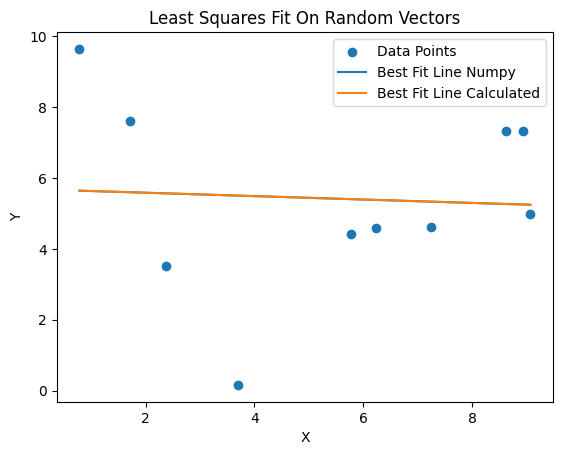

In [37]:
Y_guess = (m_built * X) + c_built
Y_guess2 = (m_own * X) + c_own
plt.scatter(X, Y, label="Data Points")
plt.plot(X, Y_guess, label="Best Fit Line Numpy")
plt.plot(X, Y_guess2, label="Best Fit Line Calculated")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Least Squares Fit On Random Vectors")
plt.legend()
plt.show() #random vectors still show poor correlation

In [38]:
X = np.arange(0, 1.01, 0.01) #Linear equation with noise
w = np.random.rand()
b = np.random.rand()
Y = (w * X) + b
Z = (np.random.rand(101) * 2) - 1
Y_perm = (w * X) + b + Z
A = np.vstack([X, np.ones(len(X))]).T
m_built2, c_built2 = np.linalg.lstsq(A, Y_perm, rcond=None)[0]
m_own2, c_own2 = least_squares(X, Y)
print(f"Numpy Slope: {m_built2}, Numpy Intercept: {c_built2}")
print(f"Calculated Slope: {m_own2},  Calculated Intercept: {c_own2}")

Numpy Slope: 0.9304190342762143, Numpy Intercept: 0.9134193002072328
Calculated Slope: 0.8072329344429465,  Calculated Intercept: 0.9496322552445283


Numpy Largest residual error at X = . 75  with error of  1.0180554049883086
Numpy Smallest residual error at X = . 17  with error of  0.0008200259442894264
Calculated Largest residual error at X = . 19  with error of  0.982856929473964
Calculated Smallest residual error at X = . 56  with error of  0.005004405339149587


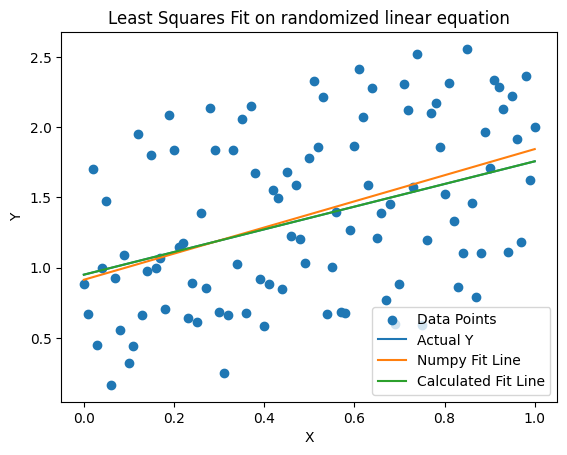

In [39]:
Y_guess1 = (m_built2 * X) + c_built2
Y_guess2 = (m_own2 * X) + c_own2
res = Y_perm - Y_guess1
max_res1 = np.argmax(np.abs(res))
min_res1 = np.argmin(np.abs(res))
res2 = Y_perm - Y_guess2
max_res2 = np.argmax(np.abs(res2))
min_res2 = np.argmin(np.abs(res2))
print("Numpy Largest residual error at X = .", max_res1, " with error of ", abs(res[max_res1]))
print("Numpy Smallest residual error at X = .", min_res1, " with error of ", abs(res[min_res1]))
print("Calculated Largest residual error at X = .", max_res2, " with error of ", abs(res2[max_res2]))
print("Calculated Smallest residual error at X = .", min_res2, " with error of ", abs(res2[min_res2]))
plt.scatter(X, Y_perm, label="Data Points")
plt.plot(X, Y, label="Actual Y")
plt.plot(X, Y_guess1, label="Numpy Fit Line")
plt.plot(X, Y_guess2, label="Calculated Fit Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Least Squares Fit on randomized linear equation")
plt.legend()
plt.show()

As with the random vectors, the noise vectors also see a marginal decrease in residual error using the calculated value rather than the built in function